In [1]:
import sys
sys.path.append('/Users/shufay/Documents/ad_afqmc')

import h5py
from math import floor
import numpy as np
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt

from ad_afqmc.lattices import triangular_grid

In [2]:
import matplotlib as mpl
import matplotlib.font_manager as font_manager
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import rcParams
import matplotlib.colors as mcolors
plt.rc('font',family='serif')
plt.rc('xtick',labelsize=18)
plt.rc('ytick',labelsize=18)
plt.rc('axes',labelsize=20)
plt.rc('axes',titlesize=20)
plt.rc('legend',fontsize=16)
plt.rc('lines', linewidth=2)
plt.rc('savefig', dpi=300)

plt.rcParams['figure.autolayout'] =  True
plt.rcParams["font.family"] = "Serif"
cmfont = font_manager.FontProperties(fname=mpl.get_data_path() + '/fonts/ttf/cmr10.ttf')
mpl.rcParams['font.serif']=cmfont.get_name()
mpl.rcParams['mathtext.fontset']='cm'
mpl.rcParams['axes.unicode_minus']=False
plt.rcParams['figure.figsize'] = [10, 8]
colors = list(mcolors.TABLEAU_COLORS.values())

In [3]:
def linear(x, m, c):
    return m*x + c

# Load data

## Doped

In [4]:
ny = 4
bc = 'yc'
v = 0.
dt = 0.005
n_eql = 200

nwalkers = 400
path = f'./data/fe_trial/'

U_arr = [4., 8., 12.]
df_cpmc_fe_arr_4 = []

for iU, U in enumerate(U_arr):
    print(iU, dt, nwalkers, U)
    try: 
        df_cpmc = pd.read_csv(f'{path}cpmc_U={U}_v={v}_dt={dt}_nwalkers={nwalkers}.csv')
        df_cpmc = df_cpmc.set_index('# nx')
        df_cpmc = df_cpmc[df_cpmc['n_eql'] == n_eql]
        df_cpmc_fe_arr_4.append(df_cpmc)

    except: print(f'No CPMC FE results for U = {U}')

0 0.005 400 4.0
1 0.005 400 8.0
2 0.005 400 12.0


In [5]:
for iU, U in enumerate(U_arr):
    print(f'\ndt, nwalkers, U =  {dt, nwalkers, U}')
    try: print(df_cpmc_fe_arr_4[iU])
    except: pass


dt, nwalkers, U =  (0.005, 400, 4.0)
       nup  ndown  n_walkers  n_eql  e_ghf      e_cpmc  err_cpmc     time  \
# nx                                                                        
4.0    4.0    4.0      400.0  200.0    0.0  -23.011761  0.000441    587.0   
8.0    8.0    8.0      400.0  200.0    0.0  -48.214319  0.000564    580.0   
12.0  12.0   12.0      400.0  200.0    0.0  -73.508823  0.000678    819.0   
16.0  16.0   16.0      400.0  200.0    0.0  -98.825265  0.000807   1450.0   
20.0  20.0   20.0      400.0  200.0    0.0 -124.154022  0.000807   2310.0   
24.0  24.0   24.0      400.0  200.0    0.0 -149.487864  0.000921   4070.0   
28.0  28.0   28.0      400.0  200.0    0.0 -174.822471  0.001208   6100.0   
36.0  36.0   36.0      400.0  200.0    0.0 -225.499391  0.001061  12300.0   

     trial  Unnamed: 10  
# nx                     
4.0     fe          NaN  
8.0     fe          NaN  
12.0    fe          NaN  
16.0    fe          NaN  
20.0    fe          NaN  
24.0    f

## Symmetry-projected

In [6]:
ny = 4
bc = 'xc'
v = 0.
dt = 0.005
n_eql = 10

nwalkers = 200
path = f'./data/symm_projected_trial/'

U_arr = [4., 8., 12.]
df_cpmc_symm_arr_4 = []

for iU, U in enumerate(U_arr):
    print(iU, dt, nwalkers, U)
    try: 
        df_cpmc = pd.read_csv(f'{path}cpmc_U={U}_v={v}_dt={dt}_nwalkers={nwalkers}.csv')
        df_cpmc = df_cpmc.set_index('# nx')
        # df_cpmc = df_cpmc[df_cpmc['n_eql'] == n_eql]
        df_cpmc_symm_arr_4.append(df_cpmc)

    except: print(f'No CPMC symm results for U = {U}')

0 0.005 200 4.0
1 0.005 200 8.0
2 0.005 200 12.0


In [7]:
for iU, U in enumerate(U_arr):
    print(f'\ndt, nwalkers, U =  {dt, nwalkers, U}')
    try: print(df_cpmc_symm_arr_4[iU])
    except: pass


dt, nwalkers, U =  (0.005, 200, 4.0)
       nup  ndown  nwalkers  n_eql      e_ghf     e_cpmc  err_cpmc    time  \
# nx                                                                         
4.0    8.0    8.0     200.0   10.0 -13.319354 -15.230398  0.004276   811.0   
6.0   12.0   12.0     200.0   10.0 -21.647960 -24.975412  0.003340   462.0   
8.0   16.0   16.0     200.0   10.0 -29.656151 -34.137050  0.002962  1900.0   
12.0  24.0   24.0     200.0   10.0 -45.758041 -52.838705  0.003597  4910.0   

      ndet               trial  Unnamed: 11  
# nx                                         
4.0   64.0  vap_s2_proj_s2_ghf          NaN  
6.0   12.0  vap_s2_proj_s2_ghf          NaN  
8.0   30.0  vap_s2_proj_s2_ghf          NaN  
12.0  12.0  vap_s2_proj_s2_ghf          NaN  

dt, nwalkers, U =  (0.005, 200, 8.0)
       nup  ndown  nwalkers  n_eql      e_ghf     e_cpmc  err_cpmc     time  \
# nx                                                                          
4.0    8.0    8.0    

# Fit

## Doped, fit against $N_s^3$

In [8]:
res_fe_arr = []
intercept_fe_arr = [] 
intercept_err_fe_arr = [] 
    
for iU, U in enumerate(U_arr):
    try: df_cpmc = df_cpmc_fe_arr_4[iU]
    except: continue
    if df_cpmc is None: continue
    y = df_cpmc['time']
    x = (ny * df_cpmc.index)**3
    # res = scipy.stats.linregress(x[mask], y.iloc[mask])
    res = scipy.stats.linregress(x, y)
    
    print(f'\n--------------------------------------------')
    print(f'U = {U}')
    print(f'slope = {res.slope:.5f} +/- {res.stderr:.3e}')
    print(f'intercept = {res.intercept:.5f} +/- {res.intercept_stderr:.3e}')
    print(f'rvalue = {res.rvalue:.5f}')
    print(f'pvalue = {res.pvalue:.5f}')

    res_fe_arr.append(res)
    intercept_fe_arr.append(res.intercept)
    intercept_err_fe_arr.append(res.intercept_stderr)

intercept_fe_arr = np.array(intercept_fe_arr)
intercept_err_fe_arr = np.array(intercept_err_fe_arr)


--------------------------------------------
U = 4.0
slope = 0.00398 +/- 3.938e-05
intercept = 444.35636 +/- 4.826e+01
rvalue = 0.99971
pvalue = 0.00000

--------------------------------------------
U = 8.0
slope = 0.00401 +/- 4.133e-05
intercept = 427.00441 +/- 5.066e+01
rvalue = 0.99968
pvalue = 0.00000

--------------------------------------------
U = 12.0
slope = 0.00412 +/- 3.774e-05
intercept = 361.37493 +/- 4.626e+01
rvalue = 0.99975
pvalue = 0.00000


Index([4096.0, 32768.0, 110592.0, 262144.0, 512000.0, 884736.0, 1404928.0,
       2985984.0],
      dtype='float64', name='# nx')
Index([4096.0, 32768.0, 110592.0, 262144.0, 512000.0, 884736.0, 1404928.0,
       2985984.0],
      dtype='float64', name='# nx')
Index([4096.0, 32768.0, 110592.0, 262144.0, 512000.0, 884736.0, 1404928.0,
       2985984.0],
      dtype='float64', name='# nx')


/var/folders/7s/34k_vnn90590lbb66qchz3c80000gn/T/ipykernel_22392/972448718.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, axs = plt.subplots(1, 3, figsize=(12, 4))


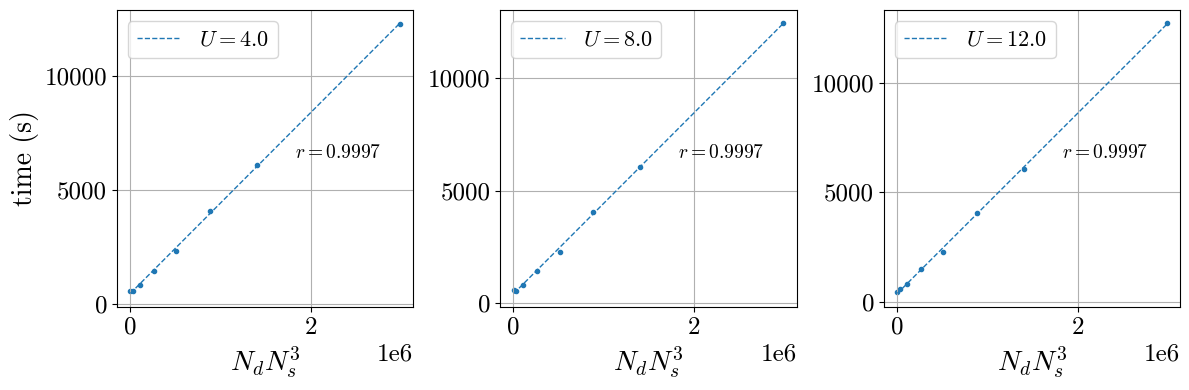

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

for iU, U in enumerate(U_arr):
    try: df_cpmc = df_cpmc_fe_arr_4[iU]
    except: continue
    if df_cpmc is None: continue
    res = res_fe_arr[iU]
    x = (ny * df_cpmc.index)**3
    y = df_cpmc['time']

    xfit = np.linspace(np.amin(x), np.amax(x), 10)
    yfit = linear(xfit, res.slope, res.intercept)
    print(x)

    ax = axs[iU]
    ax.scatter(x, y, marker='.')
    ax.plot(xfit, yfit, ls='--', lw=1, label=rf'$U = {{{U}}}$')
    ax.text(0.6, 0.5, rf"$r = {res.rvalue:.4f}$", fontsize=14, color="k", transform=ax.transAxes)
    
    ax.grid()
    ax.legend()
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.set_xlabel(r'$N_d N_s^3$')

axs[0].set_ylabel(r'time (s)')
# axs[0].set_xscale('log')
# axs[0].set_yscale('log')
plt.tight_layout()
# plt.savefig('figs/doped_timings.png', format='png', dpi=300)

## Symmetry-projected, fit against $N_d N_s^3$

In [10]:
res_symm_arr = []
intercept_symm_arr = [] 
intercept_err_symm_arr = [] 
    
for iU, U in enumerate(U_arr):
    try: df_cpmc = df_cpmc_symm_arr_4[iU]
    except: continue
    if df_cpmc is None: continue
    ndet = df_cpmc['ndet']
    y = df_cpmc['time']
    x = ndet * (ny * df_cpmc.index)**3
    # res = scipy.stats.linregress(x[mask], y.iloc[mask])
    res = scipy.stats.linregress(x, y)
    
    print(f'\n--------------------------------------------')
    print(f'U = {U}')
    print(f'slope = {res.slope:.5f} +/- {res.stderr:.3e}')
    print(f'intercept = {res.intercept:.5f} +/- {res.intercept_stderr:.3e}')
    print(f'rvalue = {res.rvalue:.5f}')
    print(f'pvalue = {res.pvalue:.5f}')

    res_symm_arr.append(res)
    intercept_symm_arr.append(res.intercept)
    intercept_err_symm_arr.append(res.intercept_stderr)

intercept_symm_arr = np.array(intercept_symm_arr)
intercept_err_symm_arr = np.array(intercept_err_symm_arr)


--------------------------------------------
U = 4.0
slope = 0.00331 +/- 9.927e-04
intercept = -243.20349 +/- 8.340e+02
rvalue = 0.92051
pvalue = 0.07949

--------------------------------------------
U = 8.0
slope = 0.00240 +/- 1.402e-04
intercept = -363.89133 +/- 7.492e+02
rvalue = 0.99491
pvalue = 0.00044

--------------------------------------------
U = 12.0
slope = 0.00228 +/- 2.093e-04
intercept = -197.59589 +/- 7.534e+02
rvalue = 0.99164
pvalue = 0.00836


# nx
4.0      262144.0
6.0      165888.0
8.0      983040.0
12.0    1327104.0
dtype: float64
# nx
4.0        65536.0
6.0      1672704.0
8.0       983040.0
10.0     4096000.0
12.0    11059200.0
dtype: float64
# nx
4.0      196608.0
6.0      276480.0
8.0     3276800.0
10.0    6400000.0
dtype: float64


/var/folders/7s/34k_vnn90590lbb66qchz3c80000gn/T/ipykernel_22392/3242073105.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, axs = plt.subplots(1, 3, figsize=(12, 4))


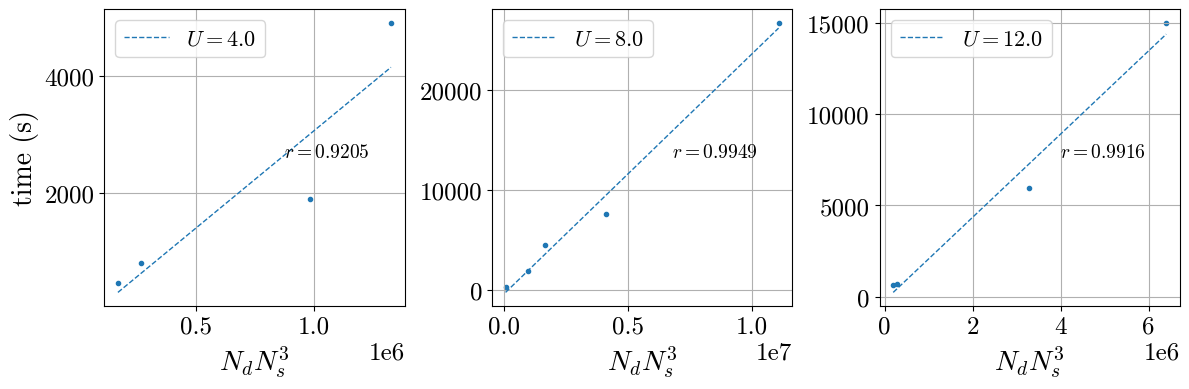

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

for iU, U in enumerate(U_arr):
    try: df_cpmc = df_cpmc_symm_arr_4[iU]
    except: continue
    if df_cpmc is None: continue
    res = res_symm_arr[iU]
    ndet = df_cpmc['ndet']
    x = ndet * (ny * df_cpmc.index)**3
    y = df_cpmc['time']

    xfit = np.linspace(np.amin(x), np.amax(x), 10)
    yfit = linear(xfit, res.slope, res.intercept)
    print(x)

    ax = axs[iU]
    ax.scatter(x, y, marker='.')
    ax.plot(xfit, yfit, ls='--', lw=1, label=rf'$U = {{{U}}}$')
    ax.text(0.6, 0.5, rf"$r = {res.rvalue:.4f}$", fontsize=14, color="k", transform=ax.transAxes)
    
    ax.grid()
    ax.legend()
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.set_xlabel(r'$N_d N_s^3$')

axs[0].set_ylabel(r'time (s)')
# axs[0].set_xscale('log')
# axs[0].set_yscale('log')
plt.tight_layout()
# plt.savefig('figs/doped_timings.png', format='png', dpi=300)

# Combine doped $U = 12$ and symmetry-projected $U = 8$

/var/folders/7s/34k_vnn90590lbb66qchz3c80000gn/T/ipykernel_22392/747355201.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, axs = plt.subplots(2, 1, figsize=(5, 8))


Index([4096.0, 32768.0, 110592.0, 262144.0, 512000.0, 884736.0, 1404928.0,
       2985984.0],
      dtype='float64', name='# nx')
# nx
4.0        65536.0
6.0      1672704.0
8.0       983040.0
10.0     4096000.0
12.0    11059200.0
dtype: float64


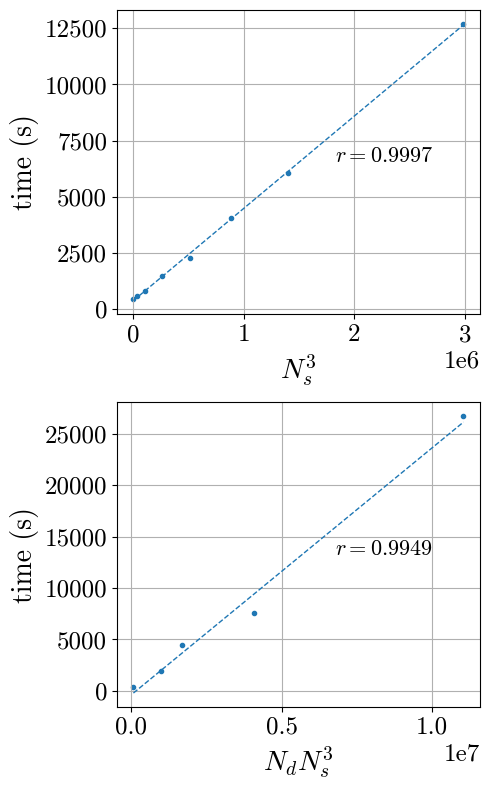

In [12]:
fig, axs = plt.subplots(2, 1, figsize=(5, 8))

# Doped, U = 12
iU = -1
U = U_arr[iU]
df_cpmc = df_cpmc_fe_arr_4[iU]
res = res_fe_arr[iU]
x = (ny * df_cpmc.index)**3
y = df_cpmc['time']

xfit = np.linspace(np.amin(x), np.amax(x), 10)
yfit = linear(xfit, res.slope, res.intercept)
print(x)

ax = axs[0]
ax.scatter(x, y, marker='.')
ax.plot(xfit, yfit, ls='--', lw=1, label=rf'$U = {{{U}}}$')
ax.text(0.6, 0.5, rf"$r = {res.rvalue:.4f}$", fontsize=16, color="k", transform=ax.transAxes)

# ax.legend()
# ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel(r'$N_s^3$')
# ax.set_title(r'YC4: $\nu = 1/2, \ U = 12$')
# ax.set_title('No symmetry projection', fontsize=18)

# Symmetry-projected, U = 8
iU = 1
U = U_arr[iU]
df_cpmc = df_cpmc_symm_arr_4[iU]
res = res_symm_arr[iU]
ndet = df_cpmc['ndet']
x = ndet * (ny * df_cpmc.index)**3
y = df_cpmc['time']

xfit = np.linspace(np.amin(x), np.amax(x), 10)
yfit = linear(xfit, res.slope, res.intercept)
print(x)

ax = axs[1]
ax.scatter(x, y, marker='.')
ax.plot(xfit, yfit, ls='--', lw=1, label=rf'$U = {{{U}}}$')
ax.text(0.6, 0.5, rf"$r = {res.rvalue:.4f}$", fontsize=16, color="k", transform=ax.transAxes)

# ax.legend()
# ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel(r'$N_d N_s^3$')
# ax.set_title(r'XC4: $\nu = 1, \ U = 8$', fontsize=18)
# ax.set_title('With symmetry projection', fontsize=18)

for ax in axs:
    ax.grid()
    ax.set_ylabel(r'time (s)')

plt.tight_layout()
# plt.savefig('timings.pdf', format='pdf', dpi=300)